<a href="https://colab.research.google.com/github/guilhermenunes-jpn/engenharia_de_prompt_aplicacoes_ai/blob/main/Aula08_Automacao_de_IA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Automação com AI

Nome: Guilherme de Pontes

#Temperatura

In [ ]:
import random # Importa o módulo random para simular a temperatura

def check_temperature():
    """
    Verifica a temperatura de um sistema (simulada) e exibe um alerta de superaquecimento
    se a temperatura exceder 30 graus Celsius.
    """
    # Em um sistema real, você obteria a temperatura aqui.
    # Por exemplo, usando bibliotecas como 'psutil' ou lendo de um sensor.
    # Para este exemplo, vamos simular uma temperatura aleatória entre 20.0 e 40.0 graus.
    simulated_temperature = random.uniform(20.0, 40.0)

    # Exibe a temperatura atual formatada para duas casas decimais usando concatenação.
    print("Temperatura atual: " + str(round(simulated_temperature, 2)) + "°C")

    # Verifica se a temperatura simulada está acima do limite de superaquecimento.
    if simulated_temperature > 30:
        print("ALERTA: Superaquecimento detectado! Temperatura acima de 30°C.")
    else:
        print("Temperatura normal.")

# Chamar a função para verificar a temperatura do sistema.
check_temperature()

Temperatura atual: 36.11°C
ALERTA: Superaquecimento detectado! Temperatura acima de 30°C.


#Consulta simples de APIs

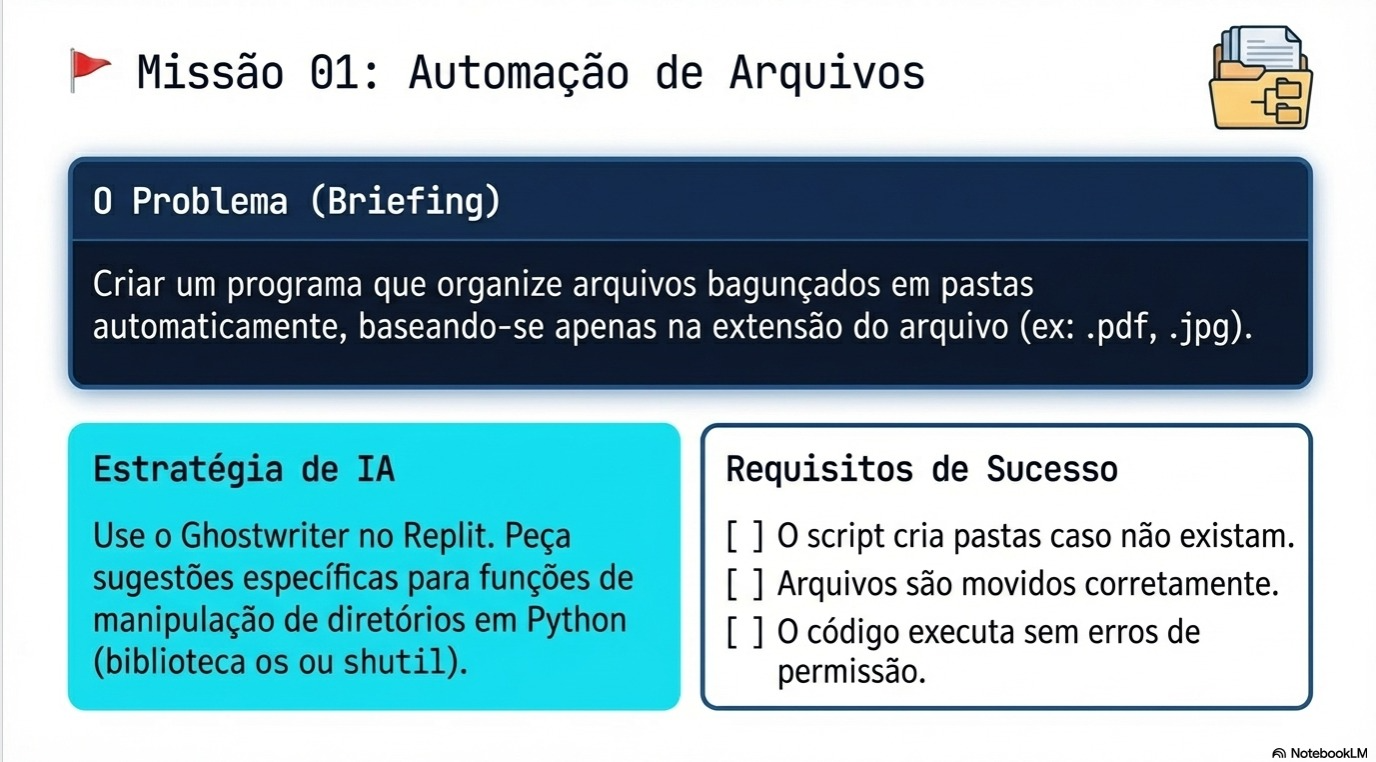

In [8]:
import os
import shutil

# Pasta onde tudo acontece
PASTA_BASE = "bagunca"

# 1. Criar a pasta base
os.makedirs(PASTA_BASE, exist_ok=True)

# 2. Criar 10 arquivos de exemplo com extensões diferentes
arquivos_exemplo = [
    "documento1.txt",
    "documento2.txt",
    "relatorio.pdf",
    "imagem1.jpg",
    "imagem2.png",
    "musica.mp3",
    "video.mp4",
    "planilha.xlsx",
    "apresentacao.pptx",
    "script.py",
]

for nome_arquivo in arquivos_exemplo:
    caminho = os.path.join(PASTA_BASE, nome_arquivo)
    with open(caminho, "w") as arquivo:
        arquivo.write("Arquivo de exemplo\n")

print("✅ 10 arquivos criados.")

# 3. Organizar arquivos por extensão
for item in os.listdir(PASTA_BASE):
    caminho_item = os.path.join(PASTA_BASE, item)

    # Ignora pastas
    if os.path.isfile(caminho_item):
        nome, extensao = os.path.splitext(item)

        # Remove o ponto da extensão
        extensao = extensao[1:].upper() or "SEM_EXTENSAO"

        # Cria pasta da extensão se não existir
        pasta_extensao = os.path.join(PASTA_BASE, extensao)
        os.makedirs(pasta_extensao, exist_ok=True)

        # Move o arquivo
        shutil.move(caminho_item, os.path.join(pasta_extensao, item))

print(" Arquivos organizados por extensão.")

✅ 10 arquivos criados.
 Arquivos organizados por extensão.


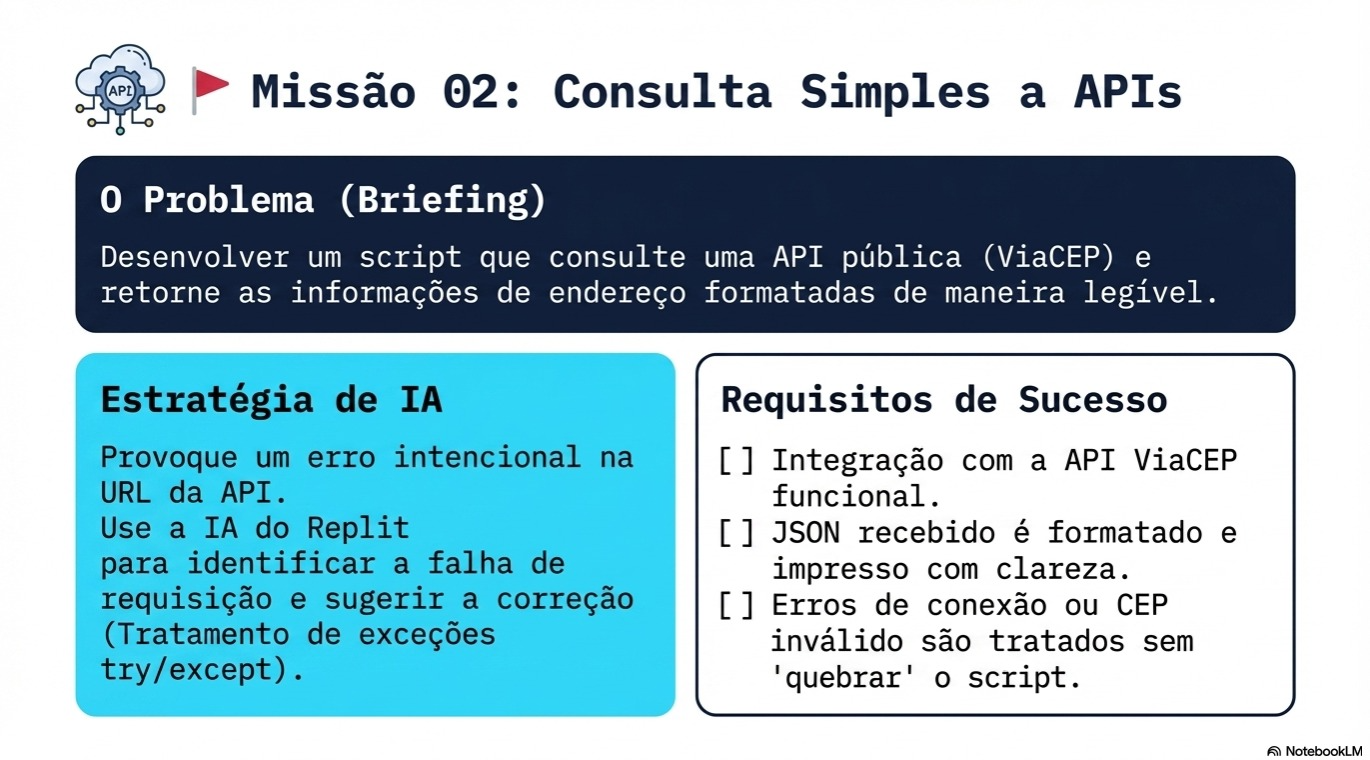

In [10]:
import requests

VIA_CEP_BASE_URL = "https://viacep.com.br/ws/"

def consultar_cep(cep: str) -> dict:
    """
    Consulta um CEP na API viaCEP e retorna os dados do endereço.

    Args:
        cep (str): O CEP a ser consultado (somente números).

    Returns:
        dict: Um dicionário contendo os dados do endereço.

    Raises:
        ValueError: Se o CEP for inválido (formato incorreto ou não encontrado).
        requests.exceptions.RequestException: Se houver um erro de conexão ou HTTP.
    """
    # Remove caracteres não numéricos
    cep = ''.join(filter(str.isdigit, cep))

    if len(cep) != 8:
        raise ValueError("CEP inválido: deve conter exatamente 8 dígitos.")

    url = f"{VIA_CEP_BASE_URL}{cep}/json/"

    try:
        response = requests.get(url, timeout=5)
        response.raise_for_status()  # Erros HTTP (4xx, 5xx)

        dados = response.json()

        if dados.get("erro"): # viaCEP retorna {'erro': true} para CEPs não encontrados
            raise ValueError("CEP não encontrado.")

        return dados

    except requests.exceptions.Timeout:
        raise requests.exceptions.Timeout("Erro de conexão: tempo de resposta excedido.")
    except requests.exceptions.ConnectionError:
        raise requests.exceptions.ConnectionError("Erro de conexão: não foi possível acessar o viaCEP.")
    except requests.exceptions.HTTPError as e:
        raise requests.exceptions.HTTPError(f"Erro HTTP: {e}")
    except ValueError:
        # Re-raise the ValueError from `dados.get("erro")` if it was raised
        raise
    except Exception as e:
        # Captura outras exceções que possam ocorrer durante a resposta JSON ou outras etapas
        raise Exception(f"Erro inesperado ao consultar o CEP: {e}")


# Exemplo de uso
if __name__ == "__main__":
    cep_input = input("Digite o CEP (somente números): ")
    try:
        endereco = consultar_cep(cep_input)
        # Formatação legível do endereço
        print("\n✅ Endereço encontrado:\n")
        print(f"CEP:          {endereco.get('cep')}")
        print(f"Logradouro:   {endereco.get('logradouro')}")
        print(f"Complemento:  {endereco.get('complemento') or '—'}")
        print(f"Bairro:       {endereco.get('bairro')}")
        print(f"Cidade:       {endereco.get('localidade')}")
        print(f"UF:           {endereco.get('uf')}")
        print(f"DDD:          {endereco.get('ddd')}")
        print("-" * 40)

    except ValueError as e:
        print(f"❌ Erro: {e}")
    except requests.exceptions.RequestException as e:
        print(f"⚠️ Erro de rede/API: {e}")
    except Exception as e:
        print(f"⚠️ Erro inesperado: {e}")


Digite o CEP (somente números): 70390045

✅ Endereço encontrado:

CEP:          70390-045
Logradouro:   Quadra SEPS 704/904
Complemento:  —
Bairro:       Asa Sul
Cidade:       Brasília
UF:           DF
DDD:          61
----------------------------------------


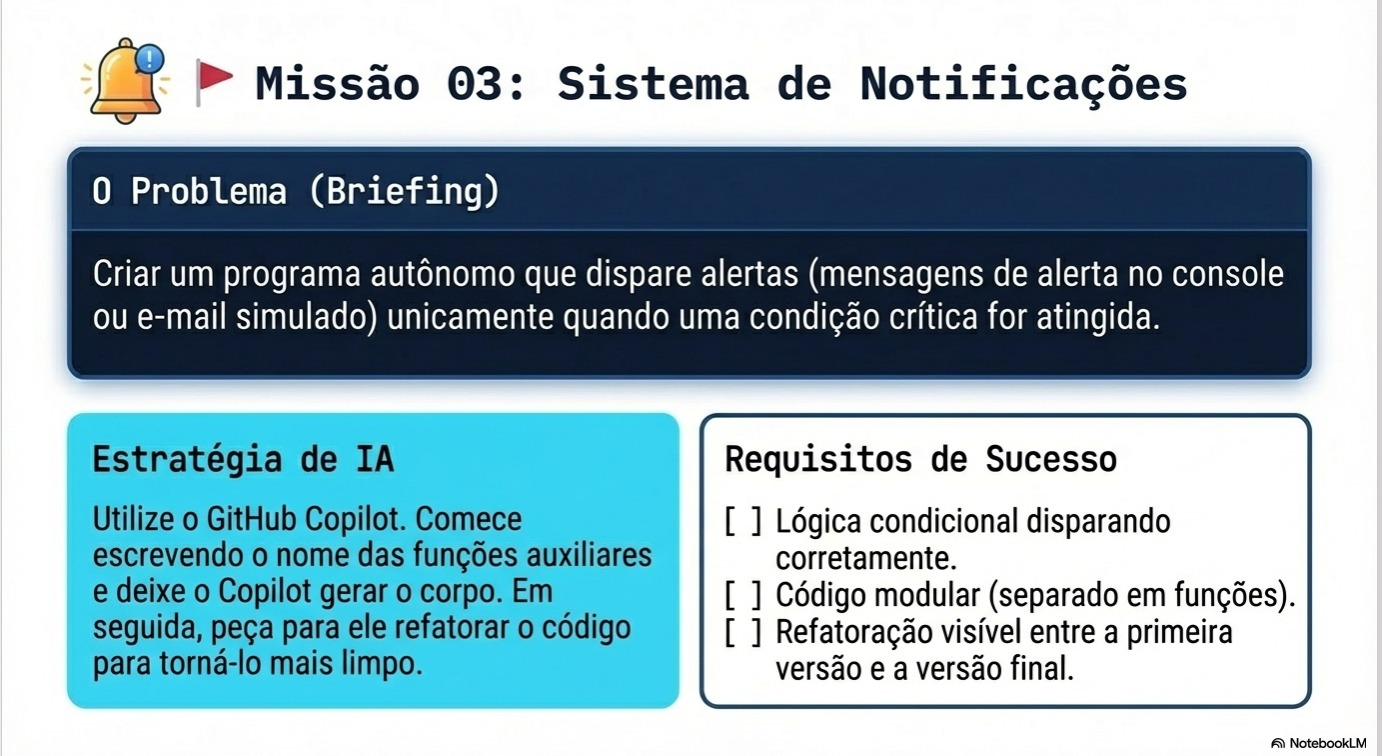

In [11]:
#Código modular e refatorado

LIMITE_CRITICO = 80


def obter_temperatura():
    """
    Simula a leitura de um sensor de temperatura
    """
    return 85


def condicao_critica(temperatura):
    """
    Verifica se a condição crítica foi atingida
    """
    return temperatura >= LIMITE_CRITICO


def disparar_alerta_console(temperatura):
    """
    Exibe alerta no console
    """
    print("⚠️ ALERTA CRÍTICO DETECTADO")
    print(f"Temperatura atual: {temperatura}°C")


def disparar_alerta_email(temperatura):
    """
    Simula o envio de um e-mail de alerta
    """
    print("📧 Simulando envio de e-mail...")
    print(f"Assunto: Alerta Crítico de Temperatura")
    print(f"Mensagem: Temperatura atingiu {temperatura}°C")


def sistema_de_monitoramento():
    """
    Função principal que executa o sistema de forma autônoma
    """
    temperatura = obter_temperatura()

    if condicao_critica(temperatura):
        disparar_alerta_console(temperatura)
        disparar_alerta_email(temperatura)
    else:
        print("✅ Sistema estável. Nenhuma ação necessária.")


# Execução autônoma
if __name__ == "__main__":
    sistema_de_monitoramento()

⚠️ ALERTA CRÍTICO DETECTADO
Temperatura atual: 85°C
📧 Simulando envio de e-mail...
Assunto: Alerta Crítico de Temperatura
Mensagem: Temperatura atingiu 85°C
